In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/content/amazon_review.csv", engine="python")

df.head()

,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up and…,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


In [3]:
df.columns

Index(['Reviewer Name', 'Profile Link', 'Country', 'Review Count',
       'Review Date', 'Rating', 'Review Title', 'Review Text',
       'Date of Experience'],
      dtype='object')

In [4]:
!pip install textblob

In [6]:
from textblob import TextBlob

def get_sentiment(text):

    if pd.isna(text):
        return "Neutral"

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Review Text"].apply(get_sentiment)

df[["Review Text","Sentiment"]].head()

,Review Text,Sentiment
0,"I registered on the website, tried to order a ...",Negative
1,Had multiple orders one turned up and driver h...,Negative
2,I informed these reprobates that I WOULD NOT B...,Negative
3,I have bought from Amazon before and no proble...,Negative
4,If I could give a lower rate I would! I cancel...,Neutral


In [8]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,10618
Negative,8344
Neutral,2252


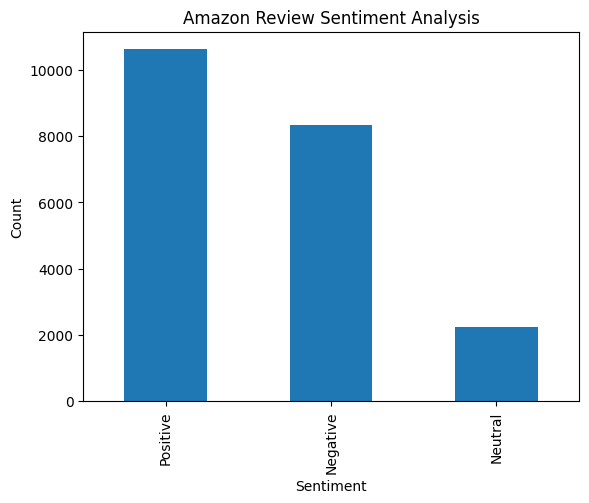

In [9]:
import matplotlib.pyplot as plt

df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Amazon Review Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [13]:
df.to_csv("sentiment_analysis_results.csv", index=False)

## Conclusion

Sentiment Analysis was performed on Amazon customer reviews using TextBlob.

The reviews were classified into Positive, Negative, and Neutral categories based on sentiment polarity.

A bar chart was created to visualize the sentiment distribution.

The results indicate that positive reviews are more common than negative and neutral reviews, suggesting generally favorable customer opinions.